# 1. Recap

In the previous labs we already covered the building blocks we'll need to train a neural network on **MNIST**:

1. **Downloading the MNIST dataset** — a classic collection of 28×28 grayscale handwritten digits.
2. **Loading images as tensors** — using `PIL` to read images and `torchvision.transforms` to convert them into PyTorch tensors.
3. **Defining a model** — a small Multi-Layer Perceptron (MLP) ready to learn to classify the digits.

In this notebook we put these pieces together and **train the model end-to-end**: prepare the data, run the training loop, monitor the loss, save the trained weights, and use them for inference.

In [1]:
# Download and extract the MNIST dataset (folders by digit class)
!wget -q https://github.com/kyuz0/mnist-png/raw/main/mnist.tgz
!tar xzf mnist.tgz

In [2]:
import os
import math
import numpy as np
from PIL import Image
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

# Open one image to confirm the data was extracted correctly
image_path = 'mnist/training/0/1.png'
image = Image.open(image_path)
image

In [3]:
# Convert a PIL image to a PyTorch tensor in [0, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
])

tensor_image = transform(image).squeeze(0)   # drop the channel dim -> (28, 28)
print(tensor_image.shape)
tensor_image

torch.Size([28, 28])


tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000

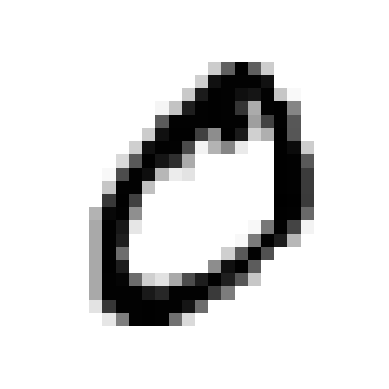

In [4]:
def imshow(tensor_image):
    """Display a (28, 28) or flat (784,) tensor as a grayscale image."""
    if tensor_image.shape[0] == 784:
        tensor_image = tensor_image.reshape(28, 28)
    plt.imshow(tensor_image, cmap='gray')
    plt.axis('off')
    plt.show()

imshow(tensor_image)

# 2. The Model

A small **Multi-Layer Perceptron** (MLP) for classifying MNIST digits.

- **Input:** flattened 28×28 image → 784 features.
- **Hidden layers:** 100 and 150 units with ReLU activations.
- **Output:** 10 logits (one per digit class). Softmax is *not* applied here — `cross_entropy` will do it for us during training.

In [ ]:
class MNISTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1 = nn.Linear(28 * 28, 100)
        self.Layer2 = nn.Linear(100, 150)
        self.Layer3 = nn.Linear(150, 10)

    def forward(self, x):
        x = F.relu(self.Layer1(x))
        x = F.relu(self.Layer2(x))
        x = F.softmax(self.Layer3(x))            # raw logits
        return x

# 3. Preparing the Data

To feed images to the model efficiently we rely on two PyTorch abstractions:

- `Dataset` — describes **how to access individual samples**.
- `DataLoader` — describes **how to iterate over them in mini-batches**.

We'll introduce each one before using it.

## 3.1 PyTorch `Dataset`

A `Dataset` is PyTorch's standard interface for representing a collection of samples. By subclassing `torch.utils.data.Dataset` we get a uniform, indexable container that hides where the data lives or how it is loaded.

**Role**

- **Encapsulate the data source** (image folders, CSV files, arrays, databases, …).
- **Apply per-sample preprocessing** (decoding, resizing, converting to tensors, …) in one place.
- **Expose a consistent indexing API** so the rest of the pipeline (`DataLoader`, training loop, …) doesn't care about the underlying format.

**Key methods to override**

| Method | Purpose |
|---|---|
| `__init__(self, ...)` | Locate the data and (optionally) cache things like file paths, labels, transforms. |
| `__len__(self)` | Return the **total number of samples** — used by `len(dataset)` and the `DataLoader`. |
| `__getitem__(self, idx)` | Load and return the **single sample** at index `idx`, typically as a `(x, y)` tuple. |

Once these three methods are implemented, the dataset behaves like any indexable Python sequence: `dataset[0]`, `for sample in dataset`, etc.

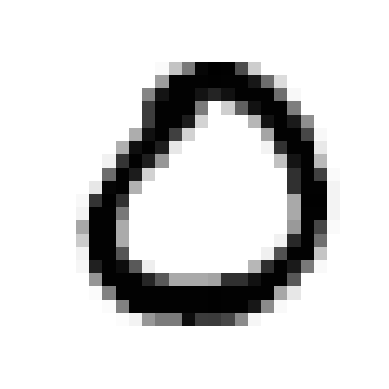

label: 0


In [ ]:
from torch.utils.data import DataLoader, Dataset


class MNISTDataset(Dataset):
    """MNIST images stored on disk as `<root>/<class>/<file>.png`."""

    def __init__(self, root_dir):
        self.root_dir = root_dir
        # Get the list of classes in the root directory
        # e.g., ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
        self.classes = sorted(
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        )
        # Build a flat list of (file_path, class_index) pairs
        # e.g., ('data/mnist/7/image1.png', 7)
        self.samples = []
        for class_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for image_name in os.listdir(class_dir):
                self.samples.append((os.path.join(class_dir, image_name), class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        # Get the image path and label at the given index
        # e.g., ('data/mnist/7/image1.png', 7)
        img_path, label = self.samples[idx]
        # Open the image
        image = Image.open(img_path)
        # Convert the image to a tensor
        # (1, 28, 28) -> (28, 28) -> (784,) so it matches the MLP input
        image = transform(image).squeeze(0).reshape(28 * 28)
        # Return the image and label
        return image, label


# Create a dataset instance
train_dataset = MNISTDataset(root_dir="mnist/training/")

# Datasets are indexable: take a peek at the first sample
image, label = train_dataset[0]
imshow(image)
print("label:", label)

## 3.2 One-Hot Encoding of Labels

One-hot encoding represents categorical labels as binary vectors: for each class we create a column, and the column matching the sample's class is `1` (all others are `0`).

![one-hot](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/3.4%20-%20Lab%20-%20Training%20MNIST%20Perceptron/one-hot-encoding.png)

MNIST has 10 classes (digits `0`–`9`). Even though they look numerical, they are **categorical** — `7` is not "greater than" `1`. One-hot encoding lets the model treat them as distinct categories without imposing an order.

Number of images: 60000


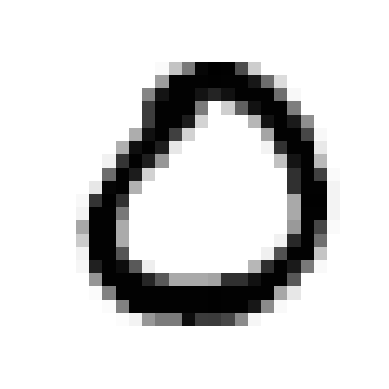

one-hot label: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


In [ ]:
class MNISTDataset(Dataset):
    """Same as before, but `__getitem__` now returns a one-hot encoded label."""

    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.classes = sorted(
            d for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        )
        self.samples = []
        for class_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for image_name in os.listdir(class_dir):
                self.samples.append((os.path.join(class_dir, image_name), class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path)
        # Convert the image to a tensor
        # (1, 28, 28) -> (28, 28) -> (784,) so it matches the MLP input
        # .squeeze(0) removes the channel dimension, which is 1 for grayscale images
        # e.g., (1, 28, 28) -> (28, 28)
        # .reshape(28 * 28) flattens the image into a 1D tensor
        # e.g., (28, 28) -> (784,)
        image = transform(image).squeeze(0).reshape(28 * 28)
        # Convert the integer label into a 10-dim one-hot float vector
        # e.g., 7 -> [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
        # Why one-hot? Because it's a good way to represent categorical data.
        # It's also a good way to represent the label for the MLP.
        y = F.one_hot(torch.tensor(label), len(self.classes)).float()
        return image, y


train_dataset = MNISTDataset(root_dir="mnist/training/")
print(f"Number of images: {len(train_dataset)}")

image, label = train_dataset[0]
imshow(image)
print("one-hot label:", label)

## 3.3 Splitting into Training and Validation Sets

We split the original training data into two disjoint subsets:

- **Training set** — used to update the model's weights.
- **Validation set** — used to monitor performance on *unseen* data **during** training, without touching the test set (which we keep for the very end).


In [8]:
from torch.utils.data import random_split

train_len = int(0.8 * len(train_dataset))      # 80% for training
val_len = len(train_dataset) - train_len       # 20% for validation

train_subset, val_subset = random_split(train_dataset, [train_len, val_len])

len(train_subset), len(val_subset)

(48000, 12000)

## 3.4 PyTorch `DataLoader`

A `DataLoader` wraps a `Dataset` and turns it into an **iterable of mini-batches**, ready to be fed to the training loop. It hides the boilerplate of batching, shuffling, parallel loading and tensor stacking.

**Role**

- **Group** individual samples into mini-batches → more stable gradient estimates and better hardware utilisation.
- **Shuffle** the training data each epoch to avoid order bias.
- **Parallelise** I/O via multiple worker processes (`num_workers`).
- **Collate** samples into batched tensors automatically.

**Key constructor arguments**

| Argument | Purpose |
|---|---|
| `dataset` | The `Dataset` instance to draw samples from. |
| `batch_size` | Number of samples per batch. |
| `shuffle` | If `True`, reshuffle the indices at every epoch (use for **training**). |
| `num_workers` | Number of subprocess workers for parallel loading (`0` = main process). |
| `drop_last` | If `True`, drop the last incomplete batch. |
| `collate_fn` | Custom function to combine a list of samples into a batch (rarely needed). |

**Typical usage**

```python
loader = DataLoader(dataset, batch_size=32, shuffle=True)
for x_batch, y_batch in loader:
    ...
```

`len(loader)` returns the **number of batches** per epoch.

![mini-batch](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/3.4%20-%20Lab%20-%20Training%20MNIST%20Perceptron/mini-batch.gif)

In [9]:
BATCH_SIZE = 32

# Shuffle the training data each epoch; keep validation order fixed
train_dl = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False)

In [10]:
# Number of batches per epoch
len(train_dl), len(val_dl)

(1500, 375)

In [11]:
# Pull a single batch from the loader to inspect its shape
for x, y in train_dl:
    print("x:", x.shape)   # (batch_size, 784)
    print("y:", y.shape)   # (batch_size, 10) one-hot
    break

x: torch.Size([32, 784])
y: torch.Size([32, 10])


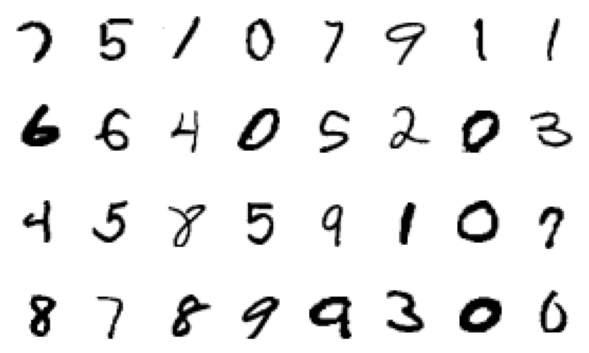

In [12]:
def display_batch(x, labels=None):
    """Show a 4x8 grid of images from a batch of size 32."""
    fig = plt.figure(figsize=(6, 4))
    for i in range(32):
        ax = fig.add_subplot(4, 8, i + 1)
        ax.imshow(x[i].reshape(28, 28), cmap='gray')
        if labels is not None:
            ax.set_title(str(labels[i]), fontsize=8)
        ax.axis('off')
    fig.tight_layout()
    plt.show()

display_batch(x)

# 4. Training Loop (mini-batch)

Training is an iterative process where, for each mini-batch, we:

1. **Forward pass** — compute predictions.
2. **Loss** — measure how wrong they are.
3. **Backward pass** — compute the gradients of the loss w.r.t. the parameters.
4. **Optimizer step** — nudge the parameters to reduce the loss.

We'll build the loop in three stages: a minimal version, one that records the loss, and a full version with validation.

![training loop](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/3.4%20-%20Lab%20-%20Training%20MNIST%20Perceptron/training-loop.png)

In [13]:
# Use the GPU if available, otherwise fall back to CPU
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Instantiate the model and move its parameters to DEVICE
model = MNISTNet().to(DEVICE)
model

Using device: cpu


/home/erradi/.venvs/ml-env/lib/python3.14/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


MNISTNet(
  (Layer1): Linear(in_features=784, out_features=100, bias=True)
  (Layer2): Linear(in_features=100, out_features=150, bias=True)
  (Layer3): Linear(in_features=150, out_features=10, bias=True)
)

### 4.1 Minimal training loop

The skeleton: forward, loss, backward, step — repeated for every batch in every epoch.

In [14]:
def train(model, dataloader, n_epochs, lr=0.01):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    model.to(DEVICE)

    for epoch in range(n_epochs):
        model.train()                              # enable training mode (gradients on)
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            y_hat = model(x)                       # 1. forward pass
            loss = F.cross_entropy(y_hat, y)       # 2. loss
            optimizer.zero_grad()                  #    clear previous gradients
            loss.backward()                        # 3. backward pass (autograd)
            optimizer.step()                       # 4. update parameters

### 4.2 Logging the loss

Same loop, but we now collect the loss for every batch and print progress periodically.

In [15]:
def train(model, dataloader, n_epochs, lr=0.01):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    batch_num = len(dataloader)

    epoch_data, loss_data = [], []
    model.to(DEVICE)

    for epoch in range(n_epochs):
        model.train()
        print(f"Epoch {epoch + 1}/{n_epochs}")

        for i, (x, y) in enumerate(dataloader):
            x, y = x.to(DEVICE), y.to(DEVICE)

            y_hat = model(x)
            loss = F.cross_entropy(y_hat, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Record progress as a fractional epoch (e.g. epoch 2.5)
            epoch_data.append(epoch + i / batch_num)
            loss_data.append(loss.item())

            if i % math.ceil(batch_num / 10) == 0:
                print(f"  batch {i + 1}/{batch_num} - loss: {loss.item():.4f}")

    return np.array(epoch_data), np.array(loss_data)

### 4.3 Full loop with validation

We add a second pass over the validation set at the end of each epoch. Inside `torch.inference_mode()` the autograd graph is **not** built, so this pass is faster and uses less memory.

In [16]:
def train(model, train_dataloader, val_dataloader, n_epochs, lr=0.01):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    batch_num = len(train_dataloader)

    epoch_data, train_loss_data, val_loss_data = [], [], []
    model.to(DEVICE)

    for epoch in range(n_epochs):
        # ---- Training ----
        model.train()
        print(f"Epoch {epoch + 1}/{n_epochs}")
        total_train_loss = 0.0

        for i, (x, y) in enumerate(train_dataloader):
            x, y = x.to(DEVICE), y.to(DEVICE)

            y_hat = model(x)
            loss = F.cross_entropy(y_hat, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            epoch_data.append(epoch + i / batch_num)
            train_loss_data.append(loss.item())

            if i % math.ceil(batch_num / 10) == 0:
                print(f"  batch {i + 1}/{batch_num} - loss: {loss.item():.4f}")

        avg_train_loss = total_train_loss / len(train_dataloader)

        # ---- Validation ----
        model.eval()                                  # disable dropout/batch-norm training behaviour
        total_val_loss = 0.0
        with torch.inference_mode():                  # no gradients needed for evaluation
            for x, y in val_dataloader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                y_hat = model(x)
                total_val_loss += F.cross_entropy(y_hat, y).item()

        avg_val_loss = total_val_loss / len(val_dataloader)
        val_loss_data.append(avg_val_loss)

        print(f"  avg train loss: {avg_train_loss:.4f} | avg val loss: {avg_val_loss:.4f}")

    return np.array(epoch_data), np.array(train_loss_data), np.array(val_loss_data)

In [17]:
# Train for a few epochs
N_EPOCHS = 5
epoch_data, train_loss_data, val_loss_data = train(model, train_dl, val_dl, n_epochs=N_EPOCHS)

Epoch 1/5
  batch 1/1500 - loss: 2.2645
  batch 151/1500 - loss: 2.2348
  batch 301/1500 - loss: 2.0440
  batch 451/1500 - loss: 1.6980
  batch 601/1500 - loss: 1.1855
  batch 751/1500 - loss: 0.7397
  batch 901/1500 - loss: 0.7432
  batch 1051/1500 - loss: 0.7729
  batch 1201/1500 - loss: 0.5035
  batch 1351/1500 - loss: 0.6616
  avg train loss: 1.2008 | avg val loss: 0.5345
Epoch 2/5
  batch 1/1500 - loss: 0.5075
  batch 151/1500 - loss: 0.4761
  batch 301/1500 - loss: 0.6288
  batch 451/1500 - loss: 0.3314
  batch 601/1500 - loss: 0.2741
  batch 751/1500 - loss: 0.6612
  batch 901/1500 - loss: 0.4342
  batch 1051/1500 - loss: 0.4660
  batch 1201/1500 - loss: 0.3126
  batch 1351/1500 - loss: 0.2409
  avg train loss: 0.4442 | avg val loss: 0.4119
Epoch 3/5
  batch 1/1500 - loss: 0.3901
  batch 151/1500 - loss: 0.3600
  batch 301/1500 - loss: 0.0970
  batch 451/1500 - loss: 0.1998
  batch 601/1500 - loss: 0.3671
  batch 751/1500 - loss: 0.2015
  batch 901/1500 - loss: 0.3824
  batch 10

## 4.4 Plotting the Loss Curves

Plotting the loss helps us **see** what training is doing:

- **Convergence** — a steadily decreasing then flattening curve means the model is learning.
- **Overfitting** — training loss going down while validation loss starts going up.
- **Hyperparameter issues** — wildly fluctuating or stagnant losses may indicate a bad learning rate or architecture.

### Loss per batch

Loss recorded after every individual batch. It's noisy because each batch is a different (small) random sample of the data — but it gives a fine-grained view of training.

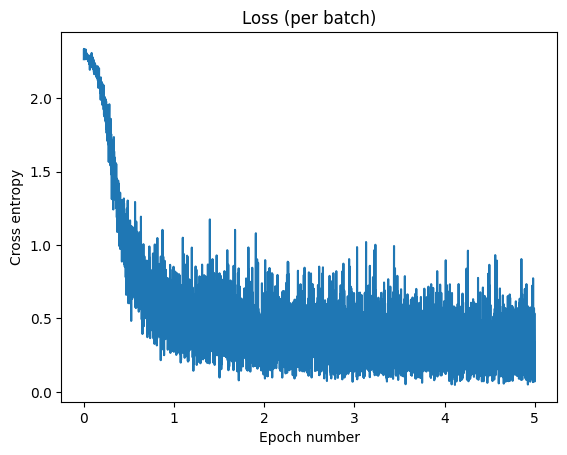

In [18]:
def plot_loss_per_batch(epoch_data, loss_data):
    plt.plot(epoch_data, loss_data)
    plt.title('Loss (per batch)')
    plt.xlabel('Epoch number')
    plt.ylabel('Cross entropy')

plot_loss_per_batch(epoch_data, train_loss_data)

### Average loss per epoch

Averaging over each epoch smooths out the noise and makes overall trends easier to read. We plot **training** and **validation** loss together to spot overfitting.

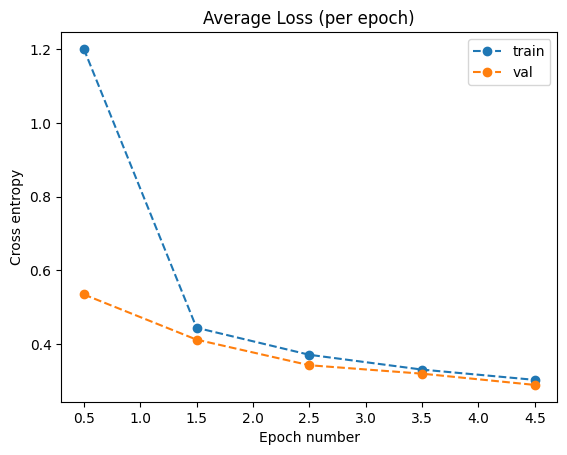

In [19]:
def plot_avg_loss_per_epoch(epoch_data, train_loss_data, val_loss_data, n_epochs):
    epoch_data_avgd  = epoch_data.reshape(n_epochs, -1).mean(axis=1)
    losses_data_avgd = train_loss_data.reshape(n_epochs, -1).mean(axis=1)

    plt.plot(epoch_data_avgd, losses_data_avgd, 'o--', label='train')
    plt.plot(epoch_data_avgd, val_loss_data,    'o--', label='val')
    plt.title('Average Loss (per epoch)')
    plt.xlabel('Epoch number')
    plt.ylabel('Cross entropy')
    plt.legend()

plot_avg_loss_per_epoch(epoch_data, train_loss_data, val_loss_data, n_epochs=N_EPOCHS)

# 5. Saving and Loading the Model

The recommended way to persist a PyTorch model is to save its **`state_dict`** — a dictionary of all learned parameters. To load:

1. Re-create the model architecture.
2. Load the saved parameters with `load_state_dict`.
3. Switch the model to evaluation mode with `.eval()` before running inference.

In [20]:
# Save only the learned parameters (not the architecture)
torch.save(model.state_dict(), 'model_state_dict.pth')

In [21]:
# Re-create the architecture, then load the parameters into it
model1 = MNISTNet()
model1.load_state_dict(torch.load('model_state_dict.pth'))
model1

MNISTNet(
  (Layer1): Linear(in_features=784, out_features=100, bias=True)
  (Layer2): Linear(in_features=100, out_features=150, bias=True)
  (Layer3): Linear(in_features=150, out_features=10, bias=True)
)

## 5.1 Inference on a Single Image

Wrap a single image into a 1-element batch, run a forward pass, and pick the class with the highest logit.

In [22]:
image_path = 'mnist/testing/0/10.png'
image = Image.open(image_path)
image

In [23]:
def recognize_digit(model, image):
    model.eval()
    x = transform(image).squeeze(0).reshape(28 * 28)   # (784,)
    with torch.inference_mode():                       # no gradients needed
        logits = model(x.unsqueeze(0))                 # add batch dim -> (1, 784)
    return logits.argmax(1).item()                     # most-likely class

In [24]:
recognize_digit(model1, image)

0

In [25]:
image_path = 'mnist/testing/7/1012.png'
image = Image.open(image_path)
recognize_digit(model1, image)

9

# 6. Batch-Size Variants

The batch size controls **how many samples** contribute to each weight update:

- **Mini-batch** (what we used): a compromise between speed and stability.
- **Full-batch**: one update per epoch — very stable but slow and memory-hungry.
- **Incremental / SGD with `batch_size=1`**: one sample per update — very noisy but fast per step.

![batch variants](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/3.4%20-%20Lab%20-%20Training%20MNIST%20Perceptron/full-batch-incremental.png)

## 6.1 Incremental Updates (`batch_size = 1`)

In [26]:
BATCH_SIZE = 1
train_incremental_dl = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
len(train_incremental_dl)

48000

In [27]:
model2 = MNISTNet().to(DEVICE)

epoch_data, train_loss_data, val_loss_data = train(
    model2, train_incremental_dl, val_dl, n_epochs=N_EPOCHS,
)

Epoch 1/5
  batch 1/48000 - loss: 2.4919
  batch 4801/48000 - loss: 0.0182
  batch 9601/48000 - loss: 0.2082
  batch 14401/48000 - loss: 0.0788
  batch 19201/48000 - loss: 0.0107
  batch 24001/48000 - loss: 0.6606
  batch 28801/48000 - loss: 0.0229
  batch 33601/48000 - loss: 0.0075
  batch 38401/48000 - loss: 0.0149
  batch 43201/48000 - loss: 1.7227
  avg train loss: 0.6047 | avg val loss: 0.3261
Epoch 2/5
  batch 1/48000 - loss: 0.0043
  batch 4801/48000 - loss: 0.0062
  batch 9601/48000 - loss: 1.6644
  batch 14401/48000 - loss: 0.0529
  batch 19201/48000 - loss: 0.0450
  batch 24001/48000 - loss: 0.0752
  batch 28801/48000 - loss: 0.0006
  batch 33601/48000 - loss: 0.0107
  batch 38401/48000 - loss: 0.0154
  batch 43201/48000 - loss: 0.0040
  avg train loss: 0.3809 | avg val loss: 0.3224
Epoch 3/5
  batch 1/48000 - loss: 0.0024
  batch 4801/48000 - loss: 1.7318
  batch 9601/48000 - loss: 0.0153
  batch 14401/48000 - loss: 3.2855
  batch 19201/48000 - loss: 0.0000
  batch 24001/480

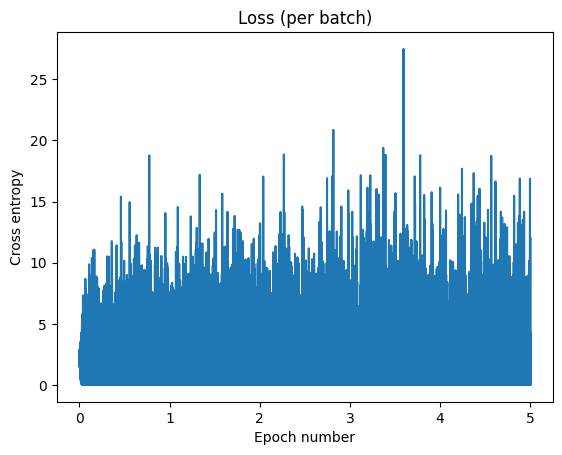

In [28]:
plot_loss_per_batch(epoch_data, train_loss_data)

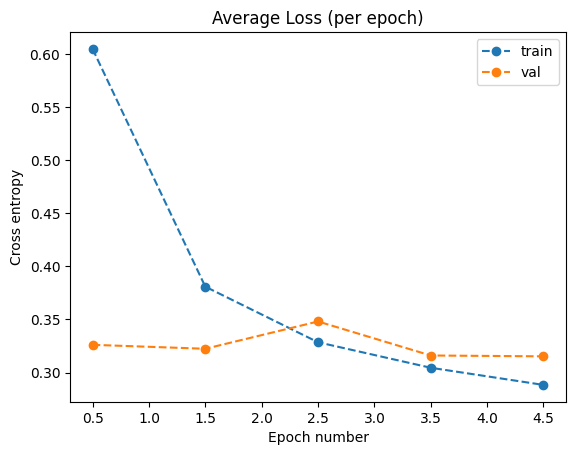

In [29]:
plot_avg_loss_per_epoch(epoch_data, train_loss_data, val_loss_data, n_epochs=N_EPOCHS)

# 7. Evaluation

Loss is essential during training, but to truly judge a model we want metrics that reflect **real classification performance** on unseen data.

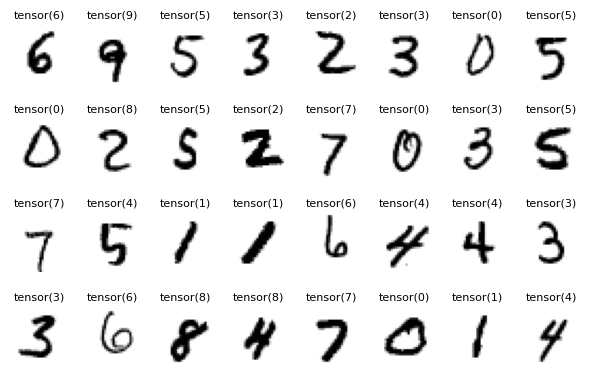

In [30]:
# A DataLoader over the held-out test set
test_dl = DataLoader(MNISTDataset(root_dir="mnist/testing/"), batch_size=32, shuffle=True)

# Show one batch alongside the model's predictions
for x, y in test_dl:
    x = x.to(DEVICE)
    y_hat = model(x)
    display_batch(x.cpu(), labels=y_hat.argmax(1).cpu())
    break

## 7.1 Accuracy

The fraction of predictions the model gets right. A simple, intuitive headline metric:

$$\text{accuracy} = \frac{\text{correct predictions}}{\text{total predictions}}$$

![accuracy](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/3.5%20-%20Lab%20-%20Evaluation/accuracy.png)

In [31]:
def calculate_accuracy(model, dataloader):
    model.to(DEVICE)
    model.eval()                                    # evaluation mode

    correct, total = 0, 0
    with torch.inference_mode():                    # no gradients
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            y_hat = model(x)
            preds = y_hat.argmax(1)
            total   += y.size(0)
            correct += (preds == y.argmax(1)).sum().item()

    return round(100 * correct / total, 2)

In [32]:
calculate_accuracy(model, test_dl)

92.08

In [33]:
calculate_accuracy(model, train_dl)

91.81

In [34]:
calculate_accuracy(model2, test_dl)

92.03

## 7.2 Confusion Matrix

A confusion matrix is a `K × K` table where rows are the **true** classes and columns are the **predicted** classes. The diagonal counts correct predictions; everything else is a mistake. Many other metrics (precision, recall, …) can be derived from it.

In [35]:
import seaborn as sns


def confusion_matrix(model, dataloader):
    num_classes = 10
    cm = torch.zeros(num_classes, num_classes)
    model.to(DEVICE)

    with torch.inference_mode():
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            y_hat = model(x)
            preds = y_hat.argmax(1)
            true  = y.argmax(1)               # one-hot -> class index
            for t, p in zip(true.view(-1), preds.view(-1)):
                cm[t.long(), p.long()] += 1

    return cm


def plot_confusion_matrix(matrix):
    plt.figure(figsize=(10, 7))
    sns.heatmap(matrix, annot=True, cmap='Greens', fmt='g', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

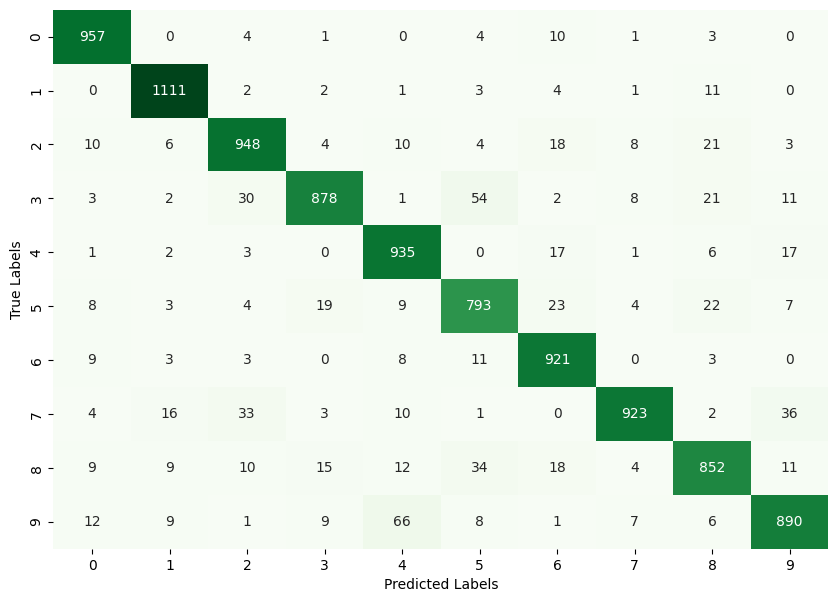

In [36]:
matrix = confusion_matrix(model, test_dl)
plot_confusion_matrix(matrix)

## 7.3 Precision and Recall (multi-class)

In binary classification:

![precision/recall](https://raw.githubusercontent.com/kyuz0/llm-chronicles/main/3.5%20-%20Lab%20-%20Evaluation/Precision-Recall.png)

For **multi-class** problems we use a **one-vs-all** view: for each class `X`, treat `X` as the positive class and all others as negative.

- **Precision for class X** — fraction of predicted-`X` samples that really are `X`.
- **Recall for class X** — fraction of actual-`X` samples the model correctly predicted as `X`.

Both can be read directly off the confusion matrix.

In [37]:
def precision_recall_from_confusion_matrix(cm):
    """Compute one-vs-all precision and recall for each class."""
    precision, recall = {}, {}
    for i in range(cm.shape[0]):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp           # predicted i but actually not i
        fn = cm[i, :].sum() - tp           # actually i but predicted as something else
        precision[i] = tp / (tp + fp)
        recall[i]    = tp / (tp + fn)
    return precision, recall


precision, recall = precision_recall_from_confusion_matrix(matrix)
for i in range(10):
    print(f"Class {i} - Precision: {precision[i]:.4f} - Recall: {recall[i]:.4f}")

Class 0 - Precision: 0.9447 - Recall: 0.9765
Class 1 - Precision: 0.9569 - Recall: 0.9789
Class 2 - Precision: 0.9133 - Recall: 0.9186
Class 3 - Precision: 0.9431 - Recall: 0.8693
Class 4 - Precision: 0.8888 - Recall: 0.9521
Class 5 - Precision: 0.8695 - Recall: 0.8890
Class 6 - Precision: 0.9083 - Recall: 0.9614
Class 7 - Precision: 0.9645 - Recall: 0.8979
Class 8 - Precision: 0.8997 - Recall: 0.8747
Class 9 - Precision: 0.9128 - Recall: 0.8821
